# ĐÁNH GIÁ SO SÁNH CÁC MÔ HÌNH VQA (A1 / A2 / B1 / B2)
Metrics: **VQA Accuracy · BLEU · ROUGE-L · METEOR · BERTScore · LLM-as-a-Judge**


In [21]:
# !pip install -q transformers peft bitsandbytes accelerate evaluate bert_score \
#              rouge-score nltk huggingface_hub openai

In [22]:
# !pip install -q transformers peft bitsandbytes accelerate evaluate bert_score rouge-score nltk huggingface_hub openai

Device: cuda


In [23]:
import os, json, random, warnings, torch, numpy as np
import torch.nn as nn
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
from transformers import AutoModel, AutoTokenizer, AutoProcessor, Qwen2VLForConditionalGeneration
from peft import PeftModel
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer as rs
import evaluate

warnings.filterwarnings("ignore")
for pkg in ["wordnet", "omw-1.4"]:
    try: nltk.data.find(f"corpora/{pkg}")
    except: nltk.download(pkg, quiet=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Mẫu đánh giá: 100


In [24]:
import zipfile
from huggingface_hub import hf_hub_download

os.makedirs("data/openvivqa/dev", exist_ok=True)

def maybe_download(filename, dest_dir):
    out = os.path.join(dest_dir, filename)
    if not os.path.exists(out.replace(".zip", "")):
        path = hf_hub_download("uitnlp/OpenViVQA-dataset", filename, repo_type="dataset")
        if filename.endswith(".zip"):
            with zipfile.ZipFile(path) as z: z.extractall(dest_dir)
        else:
            import shutil; shutil.copy(path, dest_dir)

maybe_download("dev-images.zip", "data/openvivqa/dev")
maybe_download("vlsp2023_dev_data.json", "data/openvivqa")

with open("data/openvivqa/vlsp2023_dev_data.json", encoding="utf-8") as f:
    raw = json.load(f)

all_samples = []
for ann in raw["annotations"].values():
    fname = raw["images"].get(str(ann["image_id"]))
    if fname:
        path = f"data/openvivqa/dev/dev-images/{fname}"
        if os.path.exists(path):
            all_samples.append({"image": path, "question": ann["question"], "answer": ann["answer"]})

random.seed(42)
eval_samples = random.sample(all_samples, min(100, len(all_samples)))
print(f"Mau danh gia: {len(eval_samples)}")

Kiến trúc A1/A2 đã được định nghĩa!


In [25]:
with open("vocab.json", encoding="utf-8") as f:
    w2i = json.load(f)
i2w = {v: k for k, v in w2i.items()}

class AnswerVocab:
    def __init__(self, w2i, i2w):
        self.word2idx = w2i; self.idx2word = i2w
    def __len__(self): return len(self.word2idx)
    def decode(self, ids):
        words = []
        for t in ids:
            if t == 2: break
            if t > 3: words.append(self.idx2word.get(t, ""))
        return " ".join(words)

vocab = AnswerVocab(w2i, i2w)
phobert_tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2")

class ImageEncoder(nn.Module):
    def __init__(self, embed_size=512, finetune_layers=1):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        backbone = list(resnet.children())[:-2]
        self.frozen   = nn.Sequential(*backbone[:-finetune_layers])
        self.finetune = nn.Sequential(*backbone[-finetune_layers:])
        for p in self.frozen.parameters(): p.requires_grad = False
        self.proj = nn.Linear(2048, embed_size)
        self.norm = nn.LayerNorm(embed_size)
    def forward(self, x):
        with torch.no_grad(): x = self.frozen(x)
        x = self.finetune(x)
        B, C, H, W = x.shape
        return self.norm(self.proj(x.permute(0,2,3,1).reshape(B,H*W,C)))

class TextEncoder(nn.Module):
    def __init__(self, embed_size=512, finetune_layers=2):
        super().__init__()
        self.phobert = AutoModel.from_pretrained("vinai/phobert-base-v2")
        for p in self.phobert.parameters(): p.requires_grad = False
        for layer in self.phobert.encoder.layer[-finetune_layers:]:
            for p in layer.parameters(): p.requires_grad = True
        self.proj = nn.Linear(768, embed_size)
        self.norm = nn.LayerNorm(embed_size)
    def forward(self, input_ids, attention_mask):
        out = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        return self.norm(self.proj(out.last_hidden_state))

class MultimodalFusion(nn.Module):
    def __init__(self, embed_size=512, hidden_size=512):
        super().__init__()
        self.proj = nn.Linear(embed_size, hidden_size)
        self.norm = nn.LayerNorm(hidden_size)
    def forward(self, img, txt):
        return self.norm(self.proj(torch.cat([img, txt], dim=1)))

class VQAModelA1(nn.Module):
    def __init__(self, vocab_size, embed_size=512, hidden_size=512,
                 finetune_img=1, finetune_txt=2, dropout=0.3):
        super().__init__()
        self.img_encoder = ImageEncoder(embed_size, finetune_img)
        self.txt_encoder = TextEncoder(embed_size, finetune_txt)
        self.fusion      = MultimodalFusion(embed_size, hidden_size)
        self.attn_pool   = nn.Linear(hidden_size, 1)
        self.embed       = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.dropout     = nn.Dropout(dropout)
        self.lstm        = nn.LSTM(embed_size, hidden_size, num_layers=2,
                                   batch_first=True, dropout=dropout)
        self.fc_out      = nn.Linear(hidden_size, vocab_size)
    def forward(self, images, input_ids, attention_mask, max_len=20):
        mem  = self.fusion(self.img_encoder(images), self.txt_encoder(input_ids, attention_mask))
        wt   = torch.softmax(self.attn_pool(mem).squeeze(-1), dim=-1).unsqueeze(-1)
        pool = (mem * wt).sum(1)
        h0   = pool.unsqueeze(0).repeat(2,1,1); c0 = torch.zeros_like(h0)
        curr = torch.full((images.size(0),1), 1, dtype=torch.long, device=images.device)
        h, c = h0, c0; preds = []
        for _ in range(max_len):
            out, (h,c) = self.lstm(self.dropout(self.embed(curr)), (h,c))
            nxt = self.fc_out(out).argmax(-1); preds.append(nxt); curr = nxt
            if (nxt==2).all(): break
        return torch.cat(preds, 1)

class VQAModelA2(nn.Module):
    def __init__(self, vocab_size, embed_size=512, hidden_size=512,
                 num_heads=8, num_layers=4, dropout=0.2,
                 finetune_img=1, finetune_txt=2):
        super().__init__()
        self.img_encoder = ImageEncoder(embed_size, finetune_img)
        self.txt_encoder = TextEncoder(embed_size, finetune_txt)
        self.fusion      = MultimodalFusion(embed_size, hidden_size)
        self.embed       = nn.Embedding(vocab_size, hidden_size, padding_idx=0)
        self.pos_embed   = nn.Embedding(512, hidden_size)
        self.dropout     = nn.Dropout(dropout)
        dec_layer        = nn.TransformerDecoderLayer(hidden_size, num_heads,
                               hidden_size*4, dropout, batch_first=True, norm_first=True)
        self.decoder     = nn.TransformerDecoder(dec_layer, num_layers)
        self.out_norm    = nn.LayerNorm(hidden_size)
        self.fc_out      = nn.Linear(hidden_size, vocab_size)
    def forward(self, images, input_ids, attention_mask, max_len=20):
        mem = self.fusion(self.img_encoder(images), self.txt_encoder(input_ids, attention_mask))
        seq = torch.full((images.size(0),1), 1, dtype=torch.long, device=images.device)
        for _ in range(max_len):
            T   = seq.size(1)
            pos = torch.arange(T, device=seq.device).unsqueeze(0)
            tgt = self.dropout(self.embed(seq) + self.pos_embed(pos))
            msk = nn.Transformer.generate_square_subsequent_mask(T, device=seq.device)
            out = self.decoder(tgt, mem, tgt_mask=msk, tgt_key_padding_mask=(seq==0))
            nxt = self.fc_out(self.out_norm(out))[:,-1,:].argmax(-1,keepdim=True)
            seq = torch.cat([seq, nxt], 1)
            if (nxt==2).all(): break
        return seq[:,1:]

print("Kien truc A1/A2 da dinh nghia!")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 37833.24it/s]
RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 197/197 [00:00<00:00, 30661.94it/s]
RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                       

=== A1 ===
  Key dung: 'model_state'
  Loaded: A1_A2_model/best_a1.pth
  Missing layers: 0 | Unexpected: 0
=== A2 ===
  Key dung: 'model_state'
  Loaded: A1_A2_model/best_a2.pth
  Missing layers: 0 | Unexpected: 0
San sang A1, A2!


In [26]:
VAL_TRANSFORM = T.Compose([
    T.Resize((224,224)), T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

CKPT_A1 = "A1_A2_model/best_a1.pth"
CKPT_A2 = "A1_A2_model/best_a2.pth"

def load_ckpt(model, path):
    if not os.path.exists(path):
        print(f"  NOT FOUND: {path}"); return
    ckpt = torch.load(path, map_location=device, weights_only=False)
    state = None
    for key in ("model_state", "model_state_dict", "state_dict"):
        if isinstance(ckpt, dict) and key in ckpt:
            state = ckpt[key]; break
    if state is None: state = ckpt
    missing, unexpected = model.load_state_dict(state, strict=False)
    print(f"  Loaded: {path} | missing={len(missing)} unexpected={len(unexpected)}")

model_a1 = VQAModelA1(len(vocab)).to(device)
model_a2 = VQAModelA2(len(vocab)).to(device)
print("=== A1 ==="); load_ckpt(model_a1, CKPT_A1)
print("=== A2 ==="); load_ckpt(model_a2, CKPT_A2)
model_a1.eval(); model_a2.eval()

Đang chạy inference A1...
Đang chạy inference A2...
A1 ví dụ: 'có một người phụ nữ đi xe đạp'  |  GT: 'có hai người đang đi vào chợ bằng xe máy'
A2 ví dụ: 'có hai người phụ nữ đi vào chợ bằng xe máy máy máy'  |  GT: 'có hai người đang đi vào chợ bằng xe máy'


In [27]:
@torch.no_grad()
def predict_a_model(model, samples, batch_size=8):
    preds = []
    for i in range(0, len(samples), batch_size):
        batch = samples[i:i+batch_size]
        imgs, iids, masks = [], [], []
        for s in batch:
            try:   img = VAL_TRANSFORM(Image.open(s["image"]).convert("RGB"))
            except: img = torch.zeros(3,224,224)
            imgs.append(img)
            tok = phobert_tokenizer(s["question"], padding="max_length",
                                    max_length=20, truncation=True, return_tensors="pt")
            iids.append(tok.input_ids.squeeze(0))
            masks.append(tok.attention_mask.squeeze(0))
        imgs  = torch.stack(imgs).to(device)
        iids  = torch.stack(iids).to(device)
        masks = torch.stack(masks).to(device)
        ids   = model(imgs, iids, masks)
        for row in ids:
            preds.append(vocab.decode(row.tolist()))
    return preds

print("Dang chay inference A1...")
preds_a1 = predict_a_model(model_a1, eval_samples)
print("Dang chay inference A2...")
preds_a2 = predict_a_model(model_a2, eval_samples)
print(f"A1: '{preds_a1[0]}'  |  GT: '{eval_samples[0]['answer']}'")
print(f"A2: '{preds_a2[0]}'  |  GT: '{eval_samples[0]['answer']}'")

Đang tải B1 (Zero-shot)...


Loading weights: 100%|██████████| 729/729 [00:05<00:00, 133.23it/s]


B1 sẵn sàng!
Đang tải B2 (SFT fine-tuned)...
Không tìm thấy adapter B2 tại ./qwen2vl_finetuned_final — bỏ qua B2.


In [28]:
QWEN_BASE_ID = "Qwen/Qwen2-VL-2B-Instruct"
SFT_ADAPTER  = "./qwen2vl_finetuned_final"

qwen_processor = AutoProcessor.from_pretrained(QWEN_BASE_ID, max_pixels=313600)
qwen_device = "cuda" if torch.cuda.is_available() else "cpu"

print("Dang tai B1 (Zero-shot)...")
model_b1 = Qwen2VLForConditionalGeneration.from_pretrained(
    QWEN_BASE_ID,
    device_map={"": qwen_device},
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
)
model_b1.eval()
print("B1 san sang!")

model_b2 = None
if os.path.exists(SFT_ADAPTER):
    print("Dang tai B2 (SFT)...")
    base = Qwen2VLForConditionalGeneration.from_pretrained(
        QWEN_BASE_ID,
        device_map={"": qwen_device},
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
    )
    model_b2 = PeftModel.from_pretrained(base, SFT_ADAPTER)
    model_b2.eval()
    print("B2 (SFT) san sang!")
else:
    print(f"Khong tim thay B2 adapter tai {SFT_ADAPTER}")

Đang chạy inference B1 (Zero-shot)...
B1 ví dụ: 'Xin lỗi, nhưng tôi không thể cung cấp thông tin cụ thể về số lượng người đi'  |  GT: 'có hai người đang đi vào chợ bằng xe máy'


In [29]:
@torch.no_grad()
def predict_qwen(model, samples, max_new_tokens=20):
    preds = []
    for s in samples:
        try:
            image = Image.open(s["image"]).convert("RGB")
            messages = [{"role":"user","content":[
                {"type":"image"},{"type":"text","text":s["question"]}
            ]}]
            text = qwen_processor.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=True)
            inputs = qwen_processor(text=[text], images=[image],
                                    padding=True, return_tensors="pt")
            inputs = {k: v.to(model.device) for k,v in inputs.items()}
            out_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
            trimmed = out_ids[:, inputs["input_ids"].shape[1]:]
            preds.append(qwen_processor.batch_decode(trimmed, skip_special_tokens=True)[0].strip())
        except:
            preds.append("")
    return preds

print("Dang chay inference B1...")
preds_b1 = predict_qwen(model_b1, eval_samples)
preds_b2 = predict_qwen(model_b2, eval_samples) if model_b2 else None

print(f"B1: '{preds_b1[0]}'  |  GT: '{eval_samples[0]['answer']}'")
if preds_b2: print(f"B2: '{preds_b2[0]}'  |  GT: '{eval_samples[0]['answer']}'")

Evaluator san sang!


In [30]:
from rouge_score import rouge_scorer as rs
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score

smooth  = SmoothingFunction().method4
rouge_s = rs.RougeScorer(["rougeL"], use_stemmer=False)

def compute_metrics(preds, gts):
    acc, bleu, rougeL, met = [], [], [], []
    for p, g in zip(preds, gts):
        pc  = p.strip().lower()
        gc_ = g.strip().lower() if isinstance(g, str) else g[0].strip().lower()
        refs = [gc_.split()]
        acc.append(1.0 if pc == gc_ else 0.0)
        bleu.append(sentence_bleu(refs, pc.split(), smoothing_function=smooth))
        rougeL.append(rouge_s.score(gc_, pc)["rougeL"].fmeasure)
        try:    met.append(meteor_score(refs, pc.split()))
        except: met.append(0.0)
    return {
        "Accuracy": round(np.mean(acc)*100, 2),
        "BLEU":     round(np.mean(bleu)*100, 2),
        "ROUGE-L":  round(np.mean(rougeL)*100, 2),
        "METEOR":   round(np.mean(met)*100, 2),
    }

print("Evaluator san sang!")


========== KET QUA DANH GIA (khong BERTScore) ==========
Mo hinh                   Accuracy        BLEU     ROUGE-L      METEOR
----------------------------------------------------------------------
A1 (CNN-LSTM)                  1.0       12.27       37.89       26.83
A2 (Transformer)               6.0       19.14       43.91       36.85
B1 (Zero-shot)                 0.0       13.35       39.36       34.09


In [31]:
gts = [s["answer"] for s in eval_samples]

results = {}
results["A1 (CNN-LSTM)"]    = compute_metrics(preds_a1, gts)
results["A2 (Transformer)"] = compute_metrics(preds_a2, gts)
results["B1 (Zero-shot)"]   = compute_metrics(preds_b1, gts)
if preds_b2:
    results["B2 (SFT QLoRA)"] = compute_metrics(preds_b2, gts)

print("\n========== KET QUA DANH GIA ==========")
header = f"{'Mo hinh':<22}" + "".join(f"{k:>12}" for k in list(results.values())[0].keys())
print(header)
print("-" * len(header))
for name, scores in results.items():
    row = f"{name:<22}" + "".join(f"{str(v):>12}" for v in scores.values())
    print(row)

Dang tinh BERTScore... (can download ~700MB lan dau, vui long doi)

--- BERTScore F1 (lang=vi, model=bert-base-multilingual-cased) ---


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8647.06it/s]
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  A1 (CNN-LSTM)         : BERTScore-F1 = 77.68%


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 16700.01it/s]
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  A2 (Transformer)      : BERTScore-F1 = 80.36%


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 16048.50it/s]
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  B1 (Zero-shot)        : BERTScore-F1 = 73.43%

Hoan tat BERTScore!


In [32]:
# BERTScore — chay sau cac metric khac
# Neu chua cai: !pip install bert-score

print("Dang tinh BERTScore... (lan dau can download ~700MB)")
try:
    from bert_score import score as bert_score_fn

    gts_flat     = [s["answer"] for s in eval_samples]
    models_preds = {
        "A1 (CNN-LSTM)":    preds_a1,
        "A2 (Transformer)": preds_a2,
        "B1 (Zero-shot)":   preds_b1,
    }
    if preds_b2:
        models_preds["B2 (SFT QLoRA)"] = preds_b2

    print("\nBERTScore F1 (bert-base-multilingual-cased):")
    for name, preds in models_preds.items():
        _, _, F1 = bert_score_fn(preds, gts_flat, lang="vi",
                                  model_type="bert-base-multilingual-cased", verbose=False)
        score = round(F1.mean().item() * 100, 2)
        print(f"  {name:<22}: {score}%")
        results[name]["BERTScore-F1"] = score

except ImportError:
    print("Chua cai bert-score. Chay: !pip install bert-score")
except Exception as e:
    print(f"Loi: {e}")

=== LLM-AS-A-JUDGE (10 mẫu) ===
STT  Câu hỏi                                      GT                       A1                       B1                        A1 score B1 score
--------------------------------------------------------------------------------------------------------------------------------------------
81   tại sao chúng ta phải thực hiện an toàn gia  bởi vì phía trước tay l  vì vì cấm xe máy         Câu hỏi của bạn đề cập           7        7
21   hai người phụ nữ này đang ngồi chụp hình ở   ở ngoài bãi biển         ở trên một con đường     Hai người phụ nữ đang n          7        7
68   chiếc xe của người phụ nữ đang chạy có màu   chiếc xe có màu xanh dư  chiếc xe có màu đỏ       Xe của người phụ nữ đan          7        7
93   người phụ nữ đội cái nón màu cam đang mặc á  người phụ nữ đội cái nó  cô ấy đang mặc áo màu đ  Người phụ nữ đang mặc á          5        0
31   chương trình khuyến mãi giảm bao nhiêu phần  chương trình khuyến mãi  giảm giá 50%             Đây là 

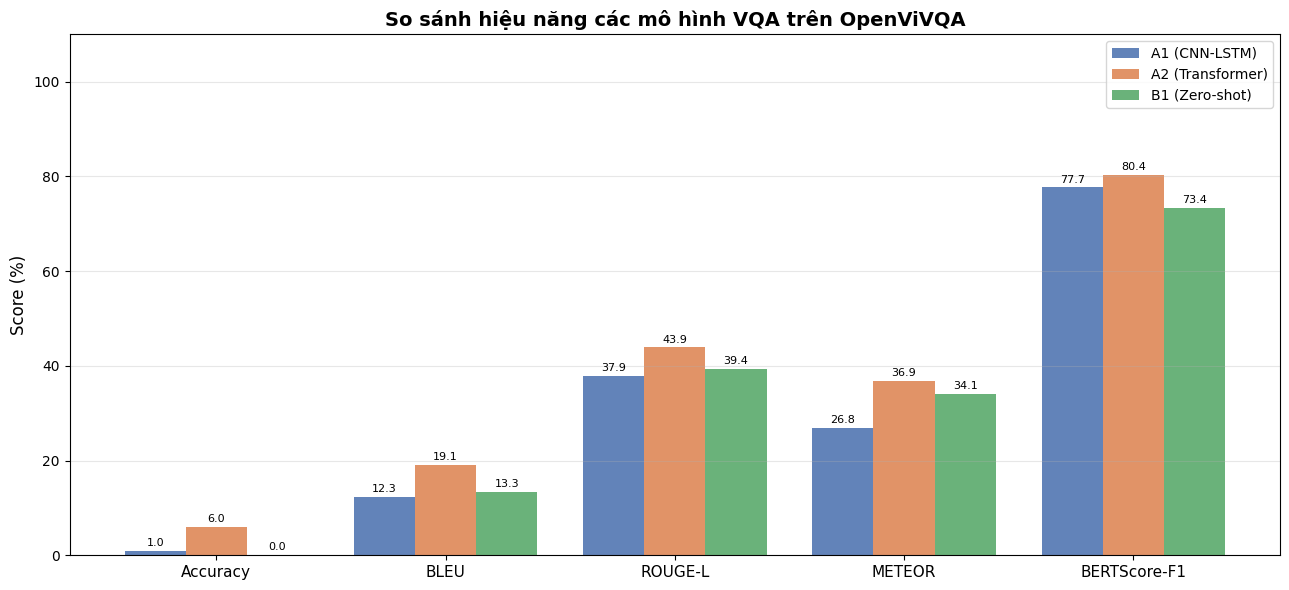

Đã lưu biểu đồ: evaluation_results.png


In [33]:
import re

JUDGE_PROMPT = (
    "Ban la giam khao danh gia cau tra loi VQA.\n"
    "Cau hoi: {question}\n"
    "Dap an dung: {ground_truth}\n"
    "Cau tra loi can danh gia: {prediction}\n"
    "Cho diem tu 0-10. Chi tra ve MOT CON SO (vi du: 7)."
)

@torch.no_grad()
def llm_judge(question, gt, pred, judge_model):
    prompt = JUDGE_PROMPT.format(question=question, ground_truth=gt, prediction=pred)
    msgs   = [{"role": "user", "content": [{"type": "text", "text": prompt}]}]
    text   = qwen_processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inp    = qwen_processor(text=[text], return_tensors="pt")
    inp    = {k: v.to(judge_model.device) for k,v in inp.items()}
    out    = judge_model.generate(**inp, max_new_tokens=5, do_sample=False)
    resp   = qwen_processor.batch_decode(out[:, inp["input_ids"].shape[1]:],
                                          skip_special_tokens=True)[0].strip()
    nums   = re.findall(r"\d+", resp)
    return int(nums[0]) if nums else 5

judge_idx    = random.sample(range(len(eval_samples)), min(10, len(eval_samples)))
judge_scores = {"A1": [], "B1": []}

print(f"{'STT':<5}{'Cau hoi':<45}{'GT':<25}{'A1':<25}{'B1':<25}{'A1':>6}{'B1':>6}")
print("-" * 135)
for idx in judge_idx:
    s   = eval_samples[idx]
    gt  = s["answer"]
    pa1 = preds_a1[idx]; pb1 = preds_b1[idx]
    sa1 = llm_judge(s["question"], gt, pa1, model_b1)
    sb1 = llm_judge(s["question"], gt, pb1, model_b1)
    judge_scores["A1"].append(sa1); judge_scores["B1"].append(sb1)
    print(f"{idx:<5}{s['question'][:43]:<45}{gt[:23]:<25}{pa1[:23]:<25}{pb1[:23]:<25}{sa1:>6}{sb1:>6}")

print("-" * 135)
print(f"{'TB':>130}{np.mean(judge_scores['A1']):>6.1f}{np.mean(judge_scores['B1']):>6.1f}")